# Build in Tools

## DuckDuckGo Search

In [18]:
from langchain_community.tools import DuckDuckGoSearchRun

In [19]:
search_tool = DuckDuckGoSearchRun()

results = search_tool.invoke('top news in india today')

print(results)

d:\Generative AI\CampusX\GenerativeAI_using_Langchain\code\.venv\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


Check today's top 10 news stories, headline news, breaking news, latest news, politics news, sports news, entertainment news and business news on Times of India India News, Latest News India: Read Live Breaking News from India along with Latest News and Today's Top Headlines Online in Bharat. Stay Up-to-date with Top news in India, current … 15 hours ago · Top News Stories of the day, Latest News Headlines, News Specials, Breaking News and Latest India News, World current affairs & Political News all around the clock at … Check out the latest news from India and around the world. Latest India news on Bollywood, Politics, Business, Cricket, Technology and Travel. News Headlines Today: Hindustan Times offers the most reliable news in politics, sports, entertainment and business, featuring National and International news Breaking News on …


In [20]:
print(search_tool.name)
print(search_tool.description)
print(search_tool.args)

duckduckgo_search
A wrapper around DuckDuckGo Search. Useful for when you need to answer questions about current events. Input should be a search query.
{'query': {'description': 'search query to look up', 'title': 'Query', 'type': 'string'}}


## Built-in Tool - Shell Tool

In [21]:
from langchain_community.tools import ShellTool

shell_tool = ShellTool()

results = shell_tool.invoke('cls')

print(results)

Executing command:
 cls



d:\Generative AI\CampusX\GenerativeAI_using_Langchain\code\.venv\Lib\site-packages\langchain_community\tools\shell\tool.py:33: UserWarning: The shell tool has no safeguards by default. Use at your own risk.
  warnings.warn(


# Custom Tools

![Screenshot 2025-08-27 145155.png](<attachment:Screenshot 2025-08-27 145155.png>)
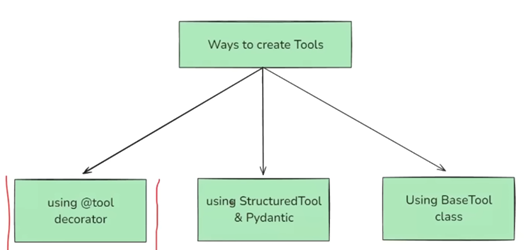

### Method 1 : using @tool

- write logic of the tool

- type hinting

- add "@tool" 

In [22]:
from langchain_core.tools import tool

In [23]:
# Step 1 : create a function

def multiply(a, b):
    """Multiply two numbers"""
    return a*b

In [24]:
# Step 2 : add type hints

def multiply(a :int, b:int) -> int:
    """Multiply two numbers"""
    return a*b

In [25]:
# Step 3 : add tool decorator
@tool
def multiply(a : int, b:int) -> int:
    """multiply two numbers"""
    return a*b
    

In [26]:
# using the tool
result = multiply.invoke({"a":3, "b":5})

In [27]:
print(result)

15


In [28]:
print(multiply.name)
print(multiply.description)
print(multiply.args)

multiply
multiply two numbers
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}


In [29]:
print(search_tool.name)
print(search_tool.description)
print(search_tool.args)

duckduckgo_search
A wrapper around DuckDuckGo Search. Useful for when you need to answer questions about current events. Input should be a search query.
{'query': {'description': 'search query to look up', 'title': 'Query', 'type': 'string'}}


In [30]:
# what LLM sees when we send it to it

print(multiply.args_schema.model_json_schema())

{'description': 'multiply two numbers', 'properties': {'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}, 'required': ['a', 'b'], 'title': 'multiply', 'type': 'object'}


### Method 2 : Using StructuredTool and pydantic

A Structured Tool in LangChain is a special type of tool where the input to the tool follows a structured schema, typically defined using a Pydantic model.


`StructuredTool.from_function`

In [31]:
from langchain.tools import StructuredTool
from pydantic import BaseModel, Field

In [33]:
class MultiplyInput(BaseModel):
    
    a : int = Field(required=True, description="the first number to add")
    b : int = Field(required=True, description="the second number to add")

d:\Generative AI\CampusX\GenerativeAI_using_Langchain\code\.venv\Lib\site-packages\pydantic\fields.py:1093: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  warn(
d:\Generative AI\CampusX\GenerativeAI_using_Langchain\code\.venv\Lib\site-packages\pydantic\fields.py:1093: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  warn(


In [34]:
def multiply_func(a: int, b : int) -> int:
    return a*b

In [ ]:
multiply_tool = StructuredTool.from_function(
    func = multiply_func,
    name = "multiply",
    description = "Multiply two numbers",
    args_schema = MultiplyInput # the pydantic class
)

In [37]:
result = multiply_tool.invoke({"a":3, "b":3})

In [38]:
print(result)
print(multiply_tool.name)
print(multiply_tool.description)
print(multiply_tool.args)

9
multiply
Multiply two numbers
{'a': {'description': 'the first number to add', 'required': True, 'title': 'A', 'type': 'integer'}, 'b': {'description': 'the second number to add', 'required': True, 'title': 'B', 'type': 'integer'}}


### Method 3 : using BaseTool class

BaseTool is the abstract base class for all tools in LangChain. It defines the core structure and interface that any tool must follow, whether it's a simple one-liner or a fully customized function.

In [39]:
from langchain.tools import BaseTool
from typing import Type

In [40]:
# arg schema using pydantic

class MultiplyInput(BaseModel):
    a: int = Field(required=True, description="The first number to add")
    b: int = Field(required=True, description="The second number to add")

d:\Generative AI\CampusX\GenerativeAI_using_Langchain\code\.venv\Lib\site-packages\pydantic\fields.py:1093: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  warn(
d:\Generative AI\CampusX\GenerativeAI_using_Langchain\code\.venv\Lib\site-packages\pydantic\fields.py:1093: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  warn(


In [42]:
class MultiplyTool(BaseTool):
    name: str = "multiply" # name of tool
    description: str = "Multiply two numbers"

    args_schema: Type[BaseModel] = MultiplyInput # type is BaseModel

    def _run(self, a: int, b: int) -> int: # name always has to be _run
        return a * b

In [43]:
multiply_tool = MultiplyTool()

In [44]:
result = multiply_tool.invoke({'a':3, 'b':3})

print(result)
print(multiply_tool.name)
print(multiply_tool.description)

print(multiply_tool.args)

9
multiply
Multiply two numbers
{'a': {'description': 'The first number to add', 'required': True, 'title': 'A', 'type': 'integer'}, 'b': {'description': 'The second number to add', 'required': True, 'title': 'B', 'type': 'integer'}}


## Toolkit

A toolkit is just a collection (bundle) of related tools that serve a common purpose — packaged together for convenience and reusability.

2 tools which are related: add and multiply

In [ ]:
from langchain_core.tools import tool

# create the needed Custom tools which are related
@tool
def add(a: int, b: int) -> int:
    """Add two numbers"""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers"""
    return a * b


In [ ]:
# class for the toolkit
class MathToolkit:
    def get_tools(self):
        return [add, multiply]

In [47]:
toolkit = MathToolkit()
tools = toolkit.get_tools()

for tool in tools:
    print(tool.name, "=>", tool.description)


add => Add two numbers
multiply => Multiply two numbers
